# 01. Diagnóstico inicial das bases

Esse notebook tem como objetivo fazer uma primeira leitura técnica das bases desse projeto.

Antes de criar target, modelar inadimplência ou propor política de crédito, eu preciso entender se os dados estão consistentes, verificando o tamanho das bases, tipos das colunas, nulos, duplicidades, datas, valores financeiros e granularidade das informações.

A ideia aqui ainda não é corrigir tudo, mas mapear os principais pontos de atenção para me orientar nas próximas etapas.

In [1]:
# Setup básico do notebook.
# eu mantenho esse bloco no início dos notebooks para garantir que o projeto
# funcione tanto no VSCode quanto no Jupyter, sem depender do diretório
# exato em que o notebook foi aberto.

import sys
from pathlib import Path

import pandas as pd
import numpy as np
import plotly.express as px

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

from concessao_credito.config import (
    CONCESSAO_PATH,
    INADIMPLENCIA_PATH,
    TABLES_DIR,
    FIGURES_DIR,
)

from concessao_credito.plots import (
    registrar_template_credito,
    aplicar_layout,
    salvar_figura,
)

# eu gosto de registrar o template visual uma única vez para padronizar os gráficos
# ao longo do projeto.
registrar_template_credito()

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:,.2f}".format)

print("Projeto:", PROJECT_ROOT)
print("Concessao:", CONCESSAO_PATH)
print("Inadimplencia:", INADIMPLENCIA_PATH)

import plotly.io as pio
pio.renderers.default = "notebook_connected+png"

Projeto: c:\GitHub\datascience\projetos\concessao_credito
Concessao: C:\GitHub\datascience\projetos\concessao_credito\data\raw\concessao.csv
Inadimplencia: C:\GitHub\datascience\projetos\concessao_credito\data\raw\inadimplencia.csv


## 1. Leitura das bases

Nesta etapa, eu faço só a leitura inicial dos arquivos. Ainda não aplico nenhum tratamento para não mascarar problemas de origem, como tipos incorretos, campos vazios ou duplicidades.

A base `concessao` representa o momento da contratação do empréstimo. Já a base `inadimplencia` acompanha mensalmente o comportamento posterior do cliente.

In [2]:
# Leitura inicial das duas bases do case.
# aqui eu ainda não faço tratamento de tipos nem filtros.

concessao = pd.read_csv(CONCESSAO_PATH)
inadimplencia = pd.read_csv(INADIMPLENCIA_PATH)

print("Shape concessao:", concessao.shape)
print("Shape inadimplencia:", inadimplencia.shape)

display(concessao.head())
display(inadimplencia.head())

Shape concessao: (30000, 13)
Shape inadimplencia: (257960, 3)


,id_cliente,data_concessao,valor_emprestado,valor_parcela,valor_taxa,valor_prazo,valor_renda,valor_restritivos,cat_escolaridade,flag_cliente_ativo,cod_agencia,data_nascimento,data_abertura_conta
0,1,2021-12-28,"4,449.81",621.66,0.05,9,"3,574.32",42.11,Fundamental Completo,1,78,1968-03-14,2019-09-04
1,2,2020-10-02,"12,822.78","1,119.39",0.04,15,"4,140.87",5.21,Médio Incompleto,1,89,1975-08-01,2019-12-06
2,3,2020-10-01,"11,683.15","1,540.47",0.04,9,"2,505.74",0.00,Médio Incompleto,1,61,1988-05-03,2019-10-22
3,4,2022-02-10,"9,704.14","1,844.53",0.04,6,"5,895.24",59.26,Não Declarado,0,11,1990-05-15,2020-09-21
4,5,2022-04-05,"17,875.28","3,937.49",0.03,5,"6,437.35",38.02,Não Declarado,1,69,1968-08-16,2020-10-19


,id_cliente,data_referencia,flag_inadimplente
0,1,2022-01-31,0
1,1,2022-02-28,0
2,1,2022-03-31,0
3,1,2022-04-30,0
4,1,2022-05-31,0


## 2. Estrutura das colunas

Aqui eu vejo os tipos lidos pelo pandas, a quantidade de nulos e o número de valores distintos por coluna.

aqui eu tô vendo basicamente
- colunas que deveriam ser datas, mas foram lidas como texto;
- variáveis financeiras com possíveis problemas;
- variáveis categóricas com muitas categorias;
- campos com nulos relevantes.

In [3]:
def diagnostico_base(df, nome_base):
    """
    Gera um resumo simples das colunas da base.

    Esse diagnóstico ajuda a identificar rapidamente:
    - tipos de dados lidos pelo pandas;
    - volume de valores ausentes;
    - quantidade de categorias ou valores distintos por variável.

    Uso essa função nas duas bases para manter a mesma leitura técnica
    e facilitar a comparação no relatório.
    """
    diagnostico = pd.DataFrame({
        "coluna": df.columns,
        "tipo": df.dtypes.astype(str).values,
        "qtd_nulos": df.isna().sum().values,
        "pct_nulos": (df.isna().mean() * 100).round(2).values,
        "qtd_unicos": df.nunique(dropna=True).values,
    })

    diagnostico["base"] = nome_base
    diagnostico = diagnostico[
        ["base", "coluna", "tipo", "qtd_nulos", "pct_nulos", "qtd_unicos"]
    ]

    return diagnostico


diag_concessao = diagnostico_base(concessao, "concessao")
diag_inadimplencia = diagnostico_base(inadimplencia, "inadimplencia")

display(diag_concessao)
display(diag_inadimplencia)

,base,coluna,tipo,qtd_nulos,pct_nulos,qtd_unicos
0,concessao,id_cliente,int64,0,0.00,30000
1,concessao,data_concessao,str,0,0.00,783
2,concessao,valor_emprestado,float64,0,0.00,29847
3,concessao,valor_parcela,float64,0,0.00,28670
4,concessao,valor_taxa,float64,0,0.00,30000
5,concessao,valor_prazo,int64,0,0.00,13
6,concessao,valor_renda,float64,0,0.00,27377
7,concessao,valor_restritivos,float64,0,0.00,12234
8,concessao,cat_escolaridade,str,414,1.38,10
9,concessao,flag_cliente_ativo,int64,0,0.00,2


,base,coluna,tipo,qtd_nulos,pct_nulos,qtd_unicos
0,inadimplencia,id_cliente,int64,0,0.00,28700
1,inadimplencia,data_referencia,str,0,0.00,35
2,inadimplencia,flag_inadimplente,int64,0,0.00,2


In [4]:
# Aqui eu guardo os diagnósticos em arquivo porque essas tabelas ajudam a documentar
# a qualidade inicial das bases e podem ser usadas depois no relatório técnico.

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

diag_concessao.to_csv(
    TABLES_DIR / "diagnostico_colunas_concessao.csv",
    index=False,
    encoding="utf-8-sig",
)

diag_inadimplencia.to_csv(
    TABLES_DIR / "diagnostico_colunas_inadimplencia.csv",
    index=False,
    encoding="utf-8-sig",
)

print("Diagnósticos salvos em:", TABLES_DIR)

Diagnósticos salvos em: C:\GitHub\datascience\projetos\concessao_credito\outputs\tables


## 3. Checagem de colunas esperadas

Antes de seguir, eu acho valido dar uma olhada se as colunas necessárias para o case estão presentes.

É mais para evitar erro silencioso mais à frente, principalmente porque o target de inadimplência em 12 meses depende das datas e do identificador do cliente.

In [5]:
colunas_esperadas_concessao = [
    "id_cliente",
    "data_concessao",
    "valor_emprestado",
    "valor_parcela",
    "valor_taxa",
    "valor_prazo",
    "valor_renda",
    "valor_restritivos",
    "cat_escolaridade",
    "flag_cliente_ativo",
    "cod_agencia",
    "data_nascimento",
    "data_abertura_conta",
]

colunas_esperadas_inadimplencia = [
    "id_cliente",
    "data_referencia",
    "flag_inadimplente",
]

faltantes_concessao = [
    col for col in colunas_esperadas_concessao
    if col not in concessao.columns
]

faltantes_inadimplencia = [
    col for col in colunas_esperadas_inadimplencia
    if col not in inadimplencia.columns
]

print("Colunas faltantes em concessao:", faltantes_concessao)
print("Colunas faltantes em inadimplencia:", faltantes_inadimplencia)

if faltantes_concessao or faltantes_inadimplencia:
    raise ValueError("Existem colunas esperadas ausentes. Verificar os arquivos de entrada.")

Colunas faltantes em concessao: []
Colunas faltantes em inadimplencia: []


## 4. Duplicidades e granularidade

Aqui eu vejo se existem linhas duplicadas e se `id_cliente` aparece mais de uma vez na base de concessão.

Esse ponto é importante porque o enunciado do case fala em identificação única do cliente, mas a base de concessões pode ter múltiplas operações para o mesmo cliente ao longo dos 3 anos. Se isso acontecer, a unidade correta de modelagem será a operação de crédito, não apenas o cliente.

In [6]:
duplicadas_concessao = concessao.duplicated().sum()
duplicadas_inadimplencia = inadimplencia.duplicated().sum()

resumo_duplicidades = pd.DataFrame({
    "base": ["concessao", "inadimplencia"],
    "qtd_linhas": [len(concessao), len(inadimplencia)],
    "qtd_duplicadas": [duplicadas_concessao, duplicadas_inadimplencia],
    "pct_duplicadas": [
        duplicadas_concessao / len(concessao) * 100,
        duplicadas_inadimplencia / len(inadimplencia) * 100,
    ],
})

display(resumo_duplicidades)

resumo_duplicidades.to_csv(
    TABLES_DIR / "resumo_duplicidades.csv",
    index=False,
    encoding="utf-8-sig",
)

,base,qtd_linhas,qtd_duplicadas,pct_duplicadas
0,concessao,30000,0,0.00
1,inadimplencia,257960,0,0.00


In [7]:
# Aqui, eu quero ver se tem mais de uma concessão para o mesmo cliente.
# Se tiver, isso muda a interpretação da base: a gente vai começar a trabalhar em nível
# de operação/contratação, e não só em nível de cliente.

freq_clientes_concessao = (
    concessao["id_cliente"]
    .value_counts()
    .reset_index()
)

freq_clientes_concessao.columns = ["id_cliente", "qtd_concessoes"]

display(freq_clientes_concessao["qtd_concessoes"].describe())

clientes_mais_de_uma_concessao = (
    freq_clientes_concessao
    .query("qtd_concessoes > 1")
    .sort_values("qtd_concessoes", ascending=False)
)

print("Clientes com mais de uma concessão:", len(clientes_mais_de_uma_concessao))

display(clientes_mais_de_uma_concessao.head(20))

count   30,000.00
mean         1.00
std          0.00
min          1.00
25%          1.00
50%          1.00
75%          1.00
max          1.00
Name: qtd_concessoes, dtype: float64

Clientes com mais de uma concessão: 0


,id_cliente,qtd_concessoes


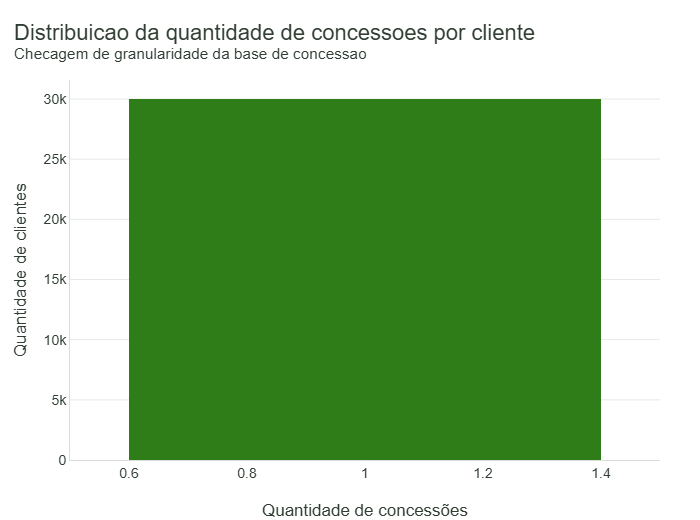

In [8]:
dist_qtd_concessoes = (
    freq_clientes_concessao
    .groupby("qtd_concessoes", as_index=False)
    .agg(qtd_clientes=("id_cliente", "count"))
)

fig = px.bar(
    dist_qtd_concessoes,
    x="qtd_concessoes",
    y="qtd_clientes",
)

fig = aplicar_layout(
    fig,
    titulo="Distribuicao da quantidade de concessoes por cliente",
    subtitulo="Checagem de granularidade da base de concessao",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Quantidade de concessões")
fig.update_yaxes(title="Quantidade de clientes")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "dist_qtd_concessoes_por_cliente.html",
)

## 5. Conversão e validação das datas

As datas são muito importantes para esse case, pq elas vão ser usadas para calcular idade na concessão, tempo de relacionamento e principalmente o target de inadimplência 12 meses após a contratação.

Por isso, eu tô convertendo as colunas de data nesta etapa pra ver se houve perda de informação na conversão.

In [9]:
# aqui eu tô criando cópias tratadas para preservar as bases originais do CSV.
# assim eu consigo comparar, se necessário, o dado bruto com o dado convertido.

concessao_tratada = concessao.copy()
inadimplencia_tratada = inadimplencia.copy()

colunas_data_concessao = [
    "data_concessao",
    "data_nascimento",
    "data_abertura_conta",
]

for col in colunas_data_concessao:
    concessao_tratada[col] = pd.to_datetime(
        concessao_tratada[col],
        errors="coerce",
    )

inadimplencia_tratada["data_referencia"] = pd.to_datetime(
    inadimplencia_tratada["data_referencia"],
    errors="coerce",
)

nulos_datas_concessao = concessao_tratada[colunas_data_concessao].isna().sum()
nulos_datas_inadimplencia = inadimplencia_tratada[["data_referencia"]].isna().sum()

display(nulos_datas_concessao)
display(nulos_datas_inadimplencia)

data_concessao         0
data_nascimento        0
data_abertura_conta    0
dtype: int64

data_referencia    0
dtype: int64

In [10]:
datas_resumo = pd.DataFrame({
    "base": [
        "concessao",
        "concessao",
        "concessao",
        "inadimplencia",
    ],
    "coluna": [
        "data_concessao",
        "data_nascimento",
        "data_abertura_conta",
        "data_referencia",
    ],
    "data_min": [
        concessao_tratada["data_concessao"].min(),
        concessao_tratada["data_nascimento"].min(),
        concessao_tratada["data_abertura_conta"].min(),
        inadimplencia_tratada["data_referencia"].min(),
    ],
    "data_max": [
        concessao_tratada["data_concessao"].max(),
        concessao_tratada["data_nascimento"].max(),
        concessao_tratada["data_abertura_conta"].max(),
        inadimplencia_tratada["data_referencia"].max(),
    ],
})

display(datas_resumo)

datas_resumo.to_csv(
    TABLES_DIR / "resumo_datas.csv",
    index=False,
    encoding="utf-8-sig",
)

,base,coluna,data_min,data_max
0,concessao,data_concessao,2019-08-20,2022-08-18
1,concessao,data_nascimento,1947-09-24,2004-08-18
2,concessao,data_abertura_conta,2009-03-31,2022-04-29
3,inadimplencia,data_referencia,2019-09-30,2022-07-31


In [11]:
# essas checagens buscam inconsistências simples, mas elas são importantes.
# por exemplo, uma conta que foi aberta depois da concessão do crédito ou nascimento depois
# à data do empréstimo pode indicar algum problema de cadastro ou de leitura memso.

checagens_datas = {
    "data_nascimento_maior_que_concessao": (
        concessao_tratada["data_nascimento"] > concessao_tratada["data_concessao"]
    ).sum(),
    "data_abertura_conta_maior_que_concessao": (
        concessao_tratada["data_abertura_conta"] > concessao_tratada["data_concessao"]
    ).sum(),
    "data_concessao_nula": concessao_tratada["data_concessao"].isna().sum(),
    "data_nascimento_nula": concessao_tratada["data_nascimento"].isna().sum(),
    "data_abertura_conta_nula": concessao_tratada["data_abertura_conta"].isna().sum(),
    "data_referencia_nula": inadimplencia_tratada["data_referencia"].isna().sum(),
}

checagens_datas_df = pd.DataFrame(
    checagens_datas.items(),
    columns=["checagem", "qtd_linhas"],
)

display(checagens_datas_df)

checagens_datas_df.to_csv(
    TABLES_DIR / "checagens_datas.csv",
    index=False,
    encoding="utf-8-sig",
)

,checagem,qtd_linhas
0,data_nascimento_maior_que_concessao,0
1,data_abertura_conta_maior_que_concessao,0
2,data_concessao_nula,0
3,data_nascimento_nula,0
4,data_abertura_conta_nula,0
5,data_referencia_nula,0


## 6. Resumo das variáveis financeiras

Agora eu vou ver as principais variáveis numéricas da operação: valor emprestado, parcela, taxa, prazo, renda e restritivos.

Essa etapa vai me ajudar a identificar outliers, valores inválidos e faixas típicas da carteira. Ela também vai ser útil depois para definir limites de política, como comprometimento máximo de renda e valor máximo concedido.

In [12]:
cols_financeiras = [
    "valor_emprestado",
    "valor_parcela",
    "valor_taxa",
    "valor_prazo",
    "valor_renda",
    "valor_restritivos",
]

resumo_financeiro = (
    concessao_tratada[cols_financeiras]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)

display(resumo_financeiro)

resumo_financeiro.to_csv(
    TABLES_DIR / "resumo_variaveis_financeiras.csv",
    encoding="utf-8-sig",
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
valor_emprestado,"30,000.00","13,121.93","12,824.40",344.98,"1,012.95","1,918.05","4,867.69","9,219.04","16,904.04","37,663.09","62,111.39","190,806.75"
valor_parcela,"30,000.00","1,805.39","1,543.78",120.54,194.49,334.79,783.23,"1,361.24","2,333.96","4,740.58","7,444.63","23,401.53"
valor_taxa,"30,000.00",0.04,0.00,0.02,0.03,0.03,0.04,0.04,0.04,0.05,0.05,0.06
valor_prazo,"30,000.00",9.03,3.73,3.00,3.00,3.00,6.00,9.00,12.00,15.00,15.00,15.00
valor_renda,"30,000.00","3,605.88","2,337.87","1,200.00","1,200.00","1,200.00","1,990.74","2,983.27","4,511.50","8,087.18","12,061.70","32,372.01"
valor_restritivos,"30,000.00",57.25,86.75,0.00,0.00,0.00,0.00,21.61,82.85,225.71,394.03,"1,231.35"


In [13]:
# Essas regras aqui não significam necessariamente que a linha vai ser removida.
# Por enquanto, elas vão servir pra mapear pontos que podem exigir tratamento
# antes da modelagem.

checagens_valores = {
    "valor_emprestado_menor_igual_zero": (
        concessao_tratada["valor_emprestado"] <= 0
    ).sum(),
    "valor_parcela_menor_igual_zero": (
        concessao_tratada["valor_parcela"] <= 0
    ).sum(),
    "valor_taxa_menor_zero": (
        concessao_tratada["valor_taxa"] < 0
    ).sum(),
    "valor_prazo_menor_igual_zero": (
        concessao_tratada["valor_prazo"] <= 0
    ).sum(),
    "valor_renda_menor_igual_zero": (
        concessao_tratada["valor_renda"] <= 0
    ).sum(),
    "valor_restritivos_menor_zero": (
        concessao_tratada["valor_restritivos"] < 0
    ).sum(),
}

checagens_valores_df = pd.DataFrame(
    checagens_valores.items(),
    columns=["checagem", "qtd_linhas"],
)

display(checagens_valores_df)

checagens_valores_df.to_csv(
    TABLES_DIR / "checagens_valores_problematicos.csv",
    index=False,
    encoding="utf-8-sig",
)

,checagem,qtd_linhas
0,valor_emprestado_menor_igual_zero,0
1,valor_parcela_menor_igual_zero,0
2,valor_taxa_menor_zero,0
3,valor_prazo_menor_igual_zero,0
4,valor_renda_menor_igual_zero,0
5,valor_restritivos_menor_zero,0


## 7. Variáveis derivadas básicas

Aqui eu tô criando algumas variáveis simples para diagnóstico:

- idade do cliente na concessão;
- tempo de conta na concessão;
- comprometimento de renda;
- restritivos sobre renda.

Essas variáveis ainda não são a versão final de modelagem, mas elas ajudam a entender a carteira e vão ser candidatas para o modelo de risco e para a política de crédito.

In [14]:
# Essas variáveis são calculadas no momento da concessão.
# Isso é importante para evitar vazamento de informação: a política precisa
# usar apenas informações disponíveis quando o cliente pede o empréstimo.

concessao_tratada["idade_concessao"] = (
    (concessao_tratada["data_concessao"] - concessao_tratada["data_nascimento"]).dt.days
    / 365.25
)

concessao_tratada["tempo_conta_anos"] = (
    (concessao_tratada["data_concessao"] - concessao_tratada["data_abertura_conta"]).dt.days
    / 365.25
)

concessao_tratada["comprometimento_renda"] = np.where(
    concessao_tratada["valor_renda"] > 0,
    concessao_tratada["valor_parcela"] / concessao_tratada["valor_renda"],
    np.nan,
)

concessao_tratada["restritivos_sobre_renda"] = np.where(
    concessao_tratada["valor_renda"] > 0,
    concessao_tratada["valor_restritivos"] / concessao_tratada["valor_renda"],
    np.nan,
)

cols_derivadas = [
    "idade_concessao",
    "tempo_conta_anos",
    "comprometimento_renda",
    "restritivos_sobre_renda",
]

resumo_derivadas = (
    concessao_tratada[cols_derivadas]
    .describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
    .T
)

display(resumo_derivadas)

resumo_derivadas.to_csv(
    TABLES_DIR / "resumo_variaveis_derivadas.csv",
    encoding="utf-8-sig",
)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
idade_concessao,"30,000.00",35.18,9.59,18.00,18.00,18.66,28.22,34.96,41.72,51.40,58.42,73.68
tempo_conta_anos,"30,000.00",1.89,1.01,0.22,0.51,0.73,1.19,1.67,2.33,3.83,5.33,11.07
comprometimento_renda,"30,000.00",0.50,0.23,0.10,0.11,0.14,0.30,0.50,0.70,0.86,0.89,0.90
restritivos_sobre_renda,"30,000.00",0.02,0.04,0.00,0.00,0.00,0.00,0.01,0.03,0.09,0.18,0.69


In [15]:
checagens_derivadas = {
    "idade_menor_18": (
        concessao_tratada["idade_concessao"] < 18
    ).sum(),
    "idade_maior_100": (
        concessao_tratada["idade_concessao"] > 100
    ).sum(),
    "tempo_conta_negativo": (
        concessao_tratada["tempo_conta_anos"] < 0
    ).sum(),
    "comprometimento_maior_100pct": (
        concessao_tratada["comprometimento_renda"] > 1
    ).sum(),
    "restritivos_maior_que_renda": (
        concessao_tratada["restritivos_sobre_renda"] > 1
    ).sum(),
}

checagens_derivadas_df = pd.DataFrame(
    checagens_derivadas.items(),
    columns=["checagem", "qtd_linhas"],
)

display(checagens_derivadas_df)

checagens_derivadas_df.to_csv(
    TABLES_DIR / "checagens_variaveis_derivadas.csv",
    index=False,
    encoding="utf-8-sig",
)

,checagem,qtd_linhas
0,idade_menor_18,1317
1,idade_maior_100,0
2,tempo_conta_negativo,0
3,comprometimento_maior_100pct,0
4,restritivos_maior_que_renda,0


## 8. Volume de concessões ao longo do tempo

Agora eu vou avaliar o volume mensal de concessões, desse jeito eu consigo verificar se a base cobre de fato uma janela histórica consistente e se existem meses com comportamento muito diferente.

Isso também vai me ajudar a planejar a validação temporal do modelo, que vai ser mais adequada do que uma divisão aleatória simples para um problema de crédito.

In [16]:
concessoes_mes = (
    concessao_tratada
    .assign(
        mes_concessao=concessao_tratada["data_concessao"].dt.to_period("M").astype(str)
    )
    .groupby("mes_concessao", as_index=False)
    .agg(
        qtd_concessoes=("id_cliente", "count"),
        qtd_clientes=("id_cliente", "nunique"),
        valor_total=("valor_emprestado", "sum"),
        valor_medio=("valor_emprestado", "mean"),
        renda_media=("valor_renda", "mean"),
    )
)

display(concessoes_mes.head())

concessoes_mes.to_csv(
    TABLES_DIR / "concessoes_por_mes.csv",
    index=False,
    encoding="utf-8-sig",
)

,mes_concessao,qtd_concessoes,qtd_clientes,valor_total,valor_medio,renda_media
0,2019-08,364,364,"4,943,774.15","13,581.80","3,567.21"
1,2019-09,821,821,"10,938,511.00","13,323.40","3,697.43"
2,2019-10,863,863,"11,923,088.46","13,815.86","3,703.41"
3,2019-11,816,816,"9,879,087.30","12,106.72","3,371.93"
4,2019-12,829,829,"10,442,159.40","12,596.09","3,539.62"


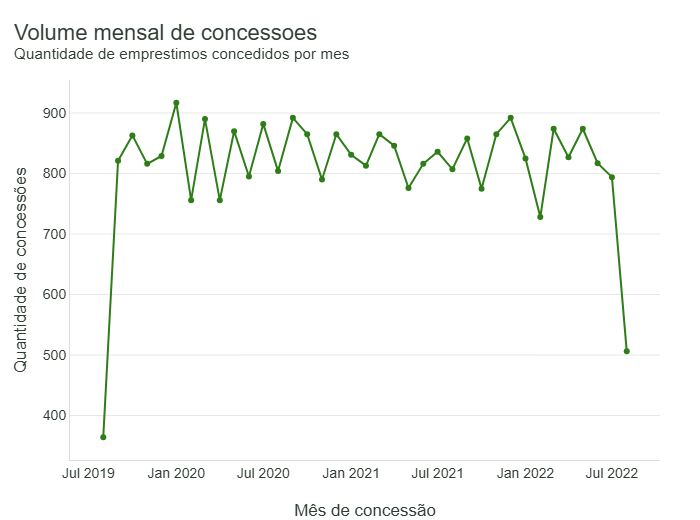

In [17]:
fig = px.line(
    concessoes_mes,
    x="mes_concessao",
    y="qtd_concessoes",
    markers=True,
)

fig = aplicar_layout(
    fig,
    titulo="Volume mensal de concessoes",
    subtitulo="Quantidade de emprestimos concedidos por mes",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Mês de concessão")
fig.update_yaxes(title="Quantidade de concessões")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "volume_mensal_concessoes.html",
)

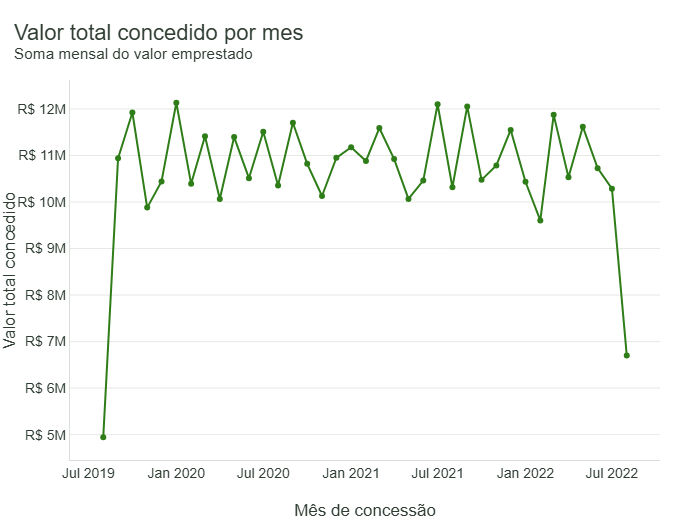

In [18]:
fig = px.line(
    concessoes_mes,
    x="mes_concessao",
    y="valor_total",
    markers=True,
)

fig = aplicar_layout(
    fig,
    titulo="Valor total concedido por mes",
    subtitulo="Soma mensal do valor emprestado",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Mês de concessão")
fig.update_yaxes(title="Valor total concedido", tickprefix="R$ ")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "valor_total_concedido_por_mes.html",
)

## 9. Distribuição das principais variáveis financeiras

Aqui nessa etapa eu tô olhando para a distribuição das variáveis financeiras mais importantes.

Esses gráficos ajudam a entender se a carteira é concentrada em valores baixos, se existem caudas longas e se vai ser necessário usar um tratamento de outliers ou transformações na modelagem.

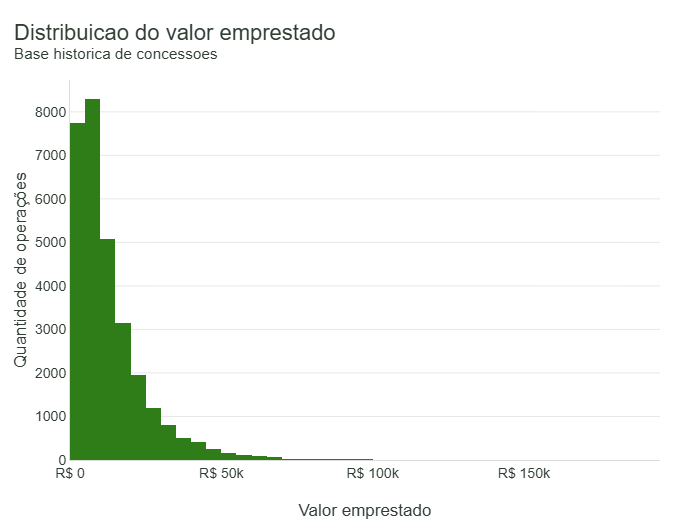

In [19]:
fig = px.histogram(
    concessao_tratada,
    x="valor_emprestado",
    nbins=40,
)

fig = aplicar_layout(
    fig,
    titulo="Distribuicao do valor emprestado",
    subtitulo="Base historica de concessoes",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Valor emprestado", tickprefix="R$ ")
fig.update_yaxes(title="Quantidade de operações")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "hist_valor_emprestado.html",
)

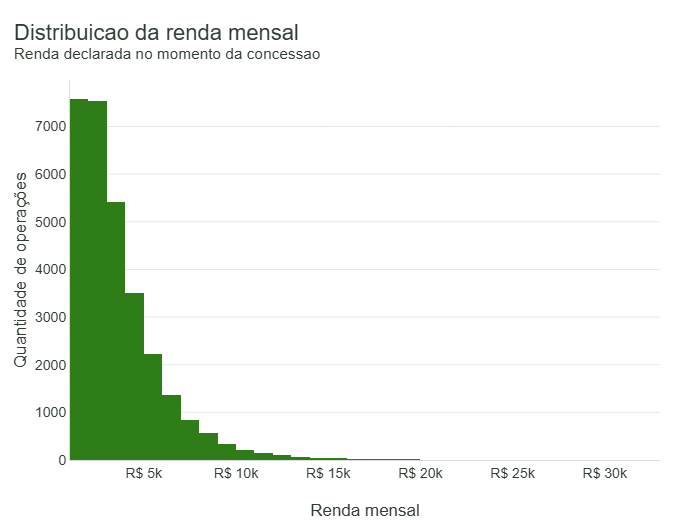

In [20]:
fig = px.histogram(
    concessao_tratada,
    x="valor_renda",
    nbins=40,
)

fig = aplicar_layout(
    fig,
    titulo="Distribuicao da renda mensal",
    subtitulo="Renda declarada no momento da concessao",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Renda mensal", tickprefix="R$ ")
fig.update_yaxes(title="Quantidade de operações")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "hist_valor_renda.html",
)

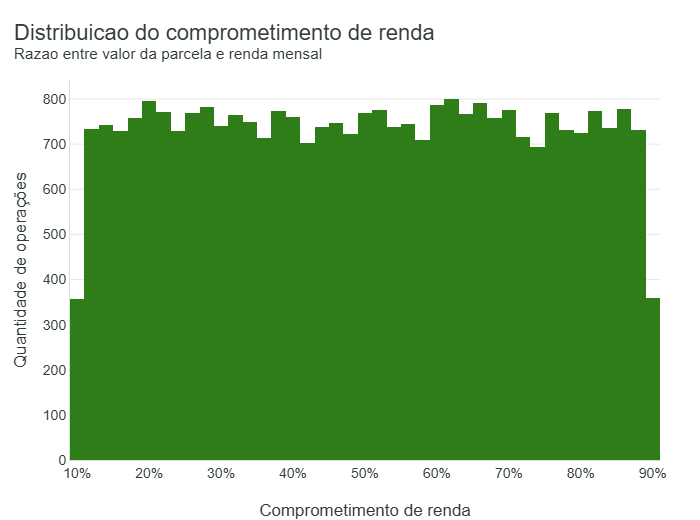

In [21]:
fig = px.histogram(
    concessao_tratada,
    x="comprometimento_renda",
    nbins=40,
)

fig = aplicar_layout(
    fig,
    titulo="Distribuicao do comprometimento de renda",
    subtitulo="Razao entre valor da parcela e renda mensal",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Comprometimento de renda", tickformat=".0%")
fig.update_yaxes(title="Quantidade de operações")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "hist_comprometimento_renda.html",
)

## 10. Variáveis categóricas

Agora eu vou a distribuição de escolaridade, cliente ativo e agência.

Essas variáveis podem ter relação com risco, mas tem que ter uma certa atenção pra isso, porque categorias muito raras podem gerar instabilidade no modelo, e agência pode carregar efeitos locais ou operacionais.

,cat_escolaridade,qtd_operacoes,valor_medio,renda_media
5,Não Declarado,4965,"12,918.38","3,546.13"
7,Sem Escolaridade,4506,"13,212.54","3,622.65"
2,Fundamental Incompleto,4167,"13,147.81","3,653.42"
1,Fundamental Incompleto,3601,"13,214.34","3,592.61"
0,Fundamental Completo,3182,"13,009.59","3,613.29"
4,Médio Incompleto,2686,"13,379.41","3,662.14"
3,Médio Completo,2308,"12,505.78","3,518.27"
9,Superior Incompleto,1871,"13,230.99","3,569.55"
8,Superior Completo,1358,"13,970.19","3,645.94"
6,Pós-graduação,942,"12,721.78","3,605.48"


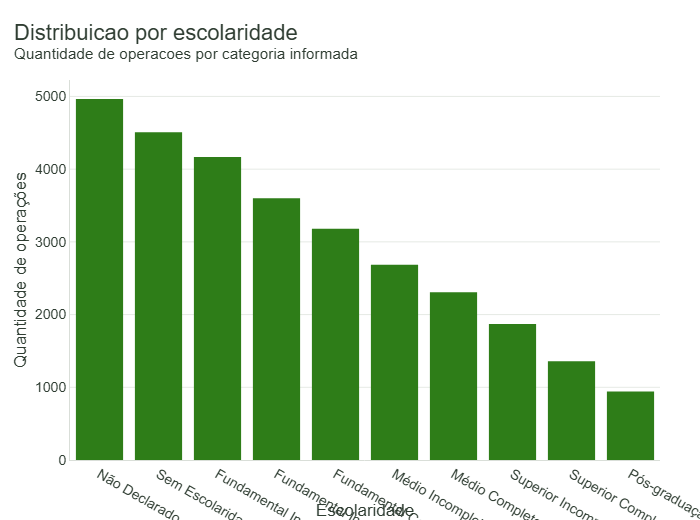

In [22]:
dist_escolaridade = (
    concessao_tratada
    .groupby("cat_escolaridade", dropna=False, as_index=False)
    .agg(
        qtd_operacoes=("id_cliente", "count"),
        valor_medio=("valor_emprestado", "mean"),
        renda_media=("valor_renda", "mean"),
    )
    .sort_values("qtd_operacoes", ascending=False)
)

display(dist_escolaridade)

dist_escolaridade.to_csv(
    TABLES_DIR / "distribuicao_escolaridade.csv",
    index=False,
    encoding="utf-8-sig",
)

fig = px.bar(
    dist_escolaridade,
    x="cat_escolaridade",
    y="qtd_operacoes",
)

fig = aplicar_layout(
    fig,
    titulo="Distribuicao por escolaridade",
    subtitulo="Quantidade de operacoes por categoria informada",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Escolaridade")
fig.update_yaxes(title="Quantidade de operações")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "dist_escolaridade.html",
)

,flag_cliente_ativo,qtd_operacoes,valor_medio,renda_media
0,0,6109,"13,117.71","3,606.15"
1,1,23891,"13,123.01","3,605.81"


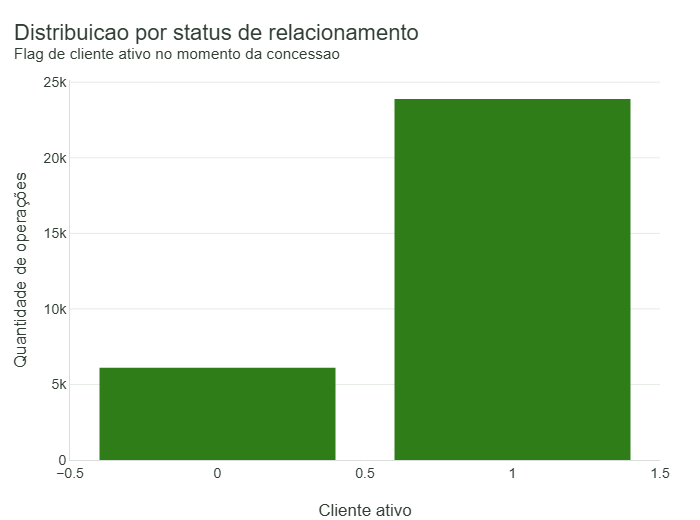

In [23]:
dist_cliente_ativo = (
    concessao_tratada
    .groupby("flag_cliente_ativo", dropna=False, as_index=False)
    .agg(
        qtd_operacoes=("id_cliente", "count"),
        valor_medio=("valor_emprestado", "mean"),
        renda_media=("valor_renda", "mean"),
    )
    .sort_values("flag_cliente_ativo")
)

display(dist_cliente_ativo)

dist_cliente_ativo.to_csv(
    TABLES_DIR / "distribuicao_cliente_ativo.csv",
    index=False,
    encoding="utf-8-sig",
)

fig = px.bar(
    dist_cliente_ativo,
    x="flag_cliente_ativo",
    y="qtd_operacoes",
)

fig = aplicar_layout(
    fig,
    titulo="Distribuicao por status de relacionamento",
    subtitulo="Flag de cliente ativo no momento da concessao",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Cliente ativo")
fig.update_yaxes(title="Quantidade de operações")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "dist_cliente_ativo.html",
)

,cod_agencia,qtd_operacoes,valor_total,valor_medio
98,99,645,"8,100,971.93","12,559.65"
97,98,618,"8,074,614.28","13,065.72"
92,93,595,"8,055,514.95","13,538.68"
94,95,591,"8,055,194.79","13,629.77"
91,92,576,"7,659,105.26","13,297.06"
88,89,567,"7,272,799.52","12,826.81"
93,94,562,"7,213,254.69","12,834.97"
90,91,561,"7,473,906.66","13,322.47"
95,96,561,"7,410,198.09","13,208.91"
96,97,558,"7,554,313.34","13,538.20"


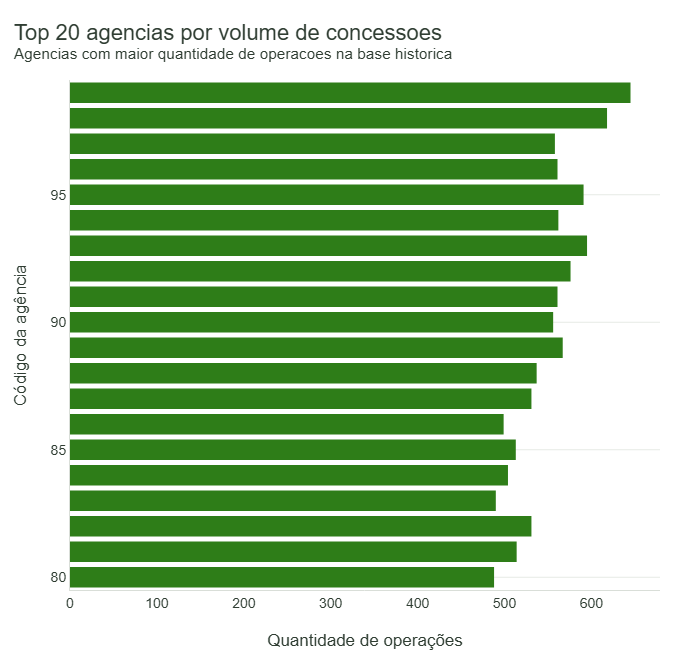

In [24]:
top_agencias = (
    concessao_tratada
    .groupby("cod_agencia", dropna=False, as_index=False)
    .agg(
        qtd_operacoes=("id_cliente", "count"),
        valor_total=("valor_emprestado", "sum"),
        valor_medio=("valor_emprestado", "mean"),
    )
    .sort_values("qtd_operacoes", ascending=False)
    .head(20)
)

display(top_agencias)

top_agencias.to_csv(
    TABLES_DIR / "top_20_agencias_concessao.csv",
    index=False,
    encoding="utf-8-sig",
)

fig = px.bar(
    top_agencias.sort_values("qtd_operacoes"),
    x="qtd_operacoes",
    y="cod_agencia",
    orientation="h",
)

fig = aplicar_layout(
    fig,
    titulo="Top 20 agencias por volume de concessoes",
    subtitulo="Agencias com maior quantidade de operacoes na base historica",
    mostrar_legenda=False,
    altura=650,
)

fig.update_xaxes(title="Quantidade de operações")
fig.update_yaxes(title="Código da agência")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "top_20_agencias_concessao.html",
)

## 11. Diagnóstico da base de inadimplência

A base de inadimplência está em formato mensal, mas antes de construir o target, eu preciso entender a sua cobertura: quantidade de registros por mês, quantidade de clientes acompanhados e taxa média de inadimplência observada.

Essa ainda não é a taxa de inadimplência final do modelo, porque o target vai ser criado em relação à concessão e à janela de 12 meses.

In [25]:
inad_mes = (
    inadimplencia_tratada
    .assign(
        mes_referencia=inadimplencia_tratada["data_referencia"].dt.to_period("M").astype(str)
    )
    .groupby("mes_referencia", as_index=False)
    .agg(
        qtd_registros=("id_cliente", "count"),
        qtd_clientes=("id_cliente", "nunique"),
        taxa_inadimplencia=("flag_inadimplente", "mean"),
    )
)

inad_mes["taxa_inadimplencia_pct"] = inad_mes["taxa_inadimplencia"] * 100

display(inad_mes.head())

inad_mes.to_csv(
    TABLES_DIR / "inadimplencia_por_mes.csv",
    index=False,
    encoding="utf-8-sig",
)

,mes_referencia,qtd_registros,qtd_clientes,taxa_inadimplencia,taxa_inadimplencia_pct
0,2019-09,364,364,0.02,2.20
1,2019-10,1185,1185,0.03,2.62
2,2019-11,2048,2048,0.03,3.03
3,2019-12,2845,2845,0.04,3.73
4,2020-01,3602,3602,0.04,4.41


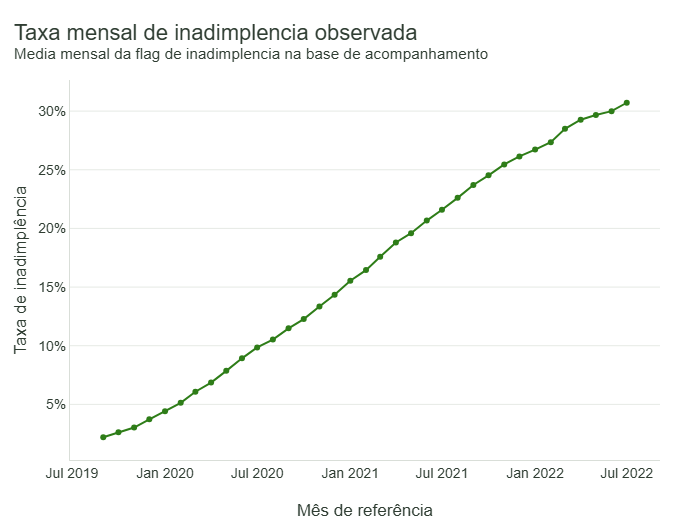

In [26]:
fig = px.line(
    inad_mes,
    x="mes_referencia",
    y="taxa_inadimplencia_pct",
    markers=True,
)

fig = aplicar_layout(
    fig,
    titulo="Taxa mensal de inadimplencia observada",
    subtitulo="Media mensal da flag de inadimplencia na base de acompanhamento",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Mês de referência")
fig.update_yaxes(title="Taxa de inadimplência", ticksuffix="%")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "taxa_mensal_inadimplencia_observada.html",
)

count   28,700.00
mean         8.99
std          6.01
min          1.00
25%          5.00
50%          8.00
75%         12.00
max         35.00
Name: qtd_meses_acompanhados, dtype: float64

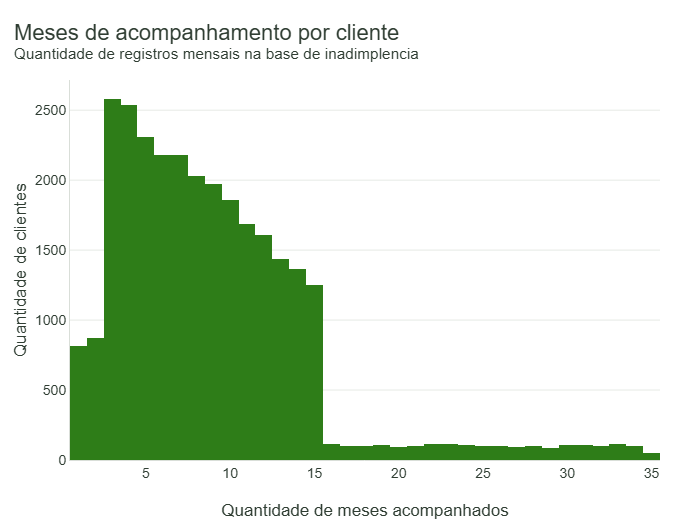

In [27]:
freq_clientes_inad = (
    inadimplencia_tratada["id_cliente"]
    .value_counts()
    .reset_index()
)

freq_clientes_inad.columns = ["id_cliente", "qtd_meses_acompanhados"]

display(freq_clientes_inad["qtd_meses_acompanhados"].describe())

fig = px.histogram(
    freq_clientes_inad,
    x="qtd_meses_acompanhados",
    nbins=40,
)

fig = aplicar_layout(
    fig,
    titulo="Meses de acompanhamento por cliente",
    subtitulo="Quantidade de registros mensais na base de inadimplencia",
    mostrar_legenda=False,
)

fig.update_xaxes(title="Quantidade de meses acompanhados")
fig.update_yaxes(title="Quantidade de clientes")

fig.show()

salvar_figura(
    fig,
    caminho_html=FIGURES_DIR / "hist_meses_acompanhados_por_cliente.html",
)

## 12. Cruzamento entre as bases

Nesta etapa aqui, eu vejo se os clientes da base de concessão aparecem na base de inadimplência.

Esse cruzamento é importante porque pra criar o target de 12 meses, eu preciso encontrar o acompanhamento posterior de cada cliente/operação.

In [28]:
clientes_concessao = set(concessao_tratada["id_cliente"].dropna().unique())
clientes_inadimplencia = set(inadimplencia_tratada["id_cliente"].dropna().unique())

clientes_ambas = clientes_concessao & clientes_inadimplencia
somente_concessao = clientes_concessao - clientes_inadimplencia
somente_inadimplencia = clientes_inadimplencia - clientes_concessao

resumo_clientes_bases = pd.DataFrame({
    "indicador": [
        "clientes_concessao",
        "clientes_inadimplencia",
        "clientes_em_ambas",
        "somente_concessao",
        "somente_inadimplencia",
    ],
    "qtd": [
        len(clientes_concessao),
        len(clientes_inadimplencia),
        len(clientes_ambas),
        len(somente_concessao),
        len(somente_inadimplencia),
    ],
})

display(resumo_clientes_bases)

resumo_clientes_bases.to_csv(
    TABLES_DIR / "resumo_clientes_bases.csv",
    index=False,
    encoding="utf-8-sig",
)

,indicador,qtd
0,clientes_concessao,30000
1,clientes_inadimplencia,28700
2,clientes_em_ambas,28700
3,somente_concessao,1300
4,somente_inadimplencia,0


In [29]:
pct_clientes_concessao_com_inad = (
    len(clientes_ambas) / len(clientes_concessao) * 100
    if len(clientes_concessao) > 0
    else np.nan
)

print(
    f"{pct_clientes_concessao_com_inad:.2f}% dos clientes da base de concessão "
    "também aparecem na base de inadimplência."
)

95.67% dos clientes da base de concessão também aparecem na base de inadimplência.


## 13. Criação de uma base tratada intermediária

No final desse diagnóstico, eu vou salvar versões intermediárias das bases com datas convertidas e variáveis derivadas básicas.

Esses arquivos ainda não são a base final de modelagem, eles servem só para evitar retrabalho nos próximos notebooks e manter uma trilha clara entre dado bruto, dado intermediário e dado final.

In [30]:
INTERIM_DIR = PROJECT_ROOT / "data" / "interim"
INTERIM_DIR.mkdir(parents=True, exist_ok=True)

concessao_tratada.to_parquet(
    INTERIM_DIR / "concessao_diagnostico.parquet",
    index=False,
)

inadimplencia_tratada.to_parquet(
    INTERIM_DIR / "inadimplencia_diagnostico.parquet",
    index=False,
)

print("Bases intermediárias salvas em:", INTERIM_DIR)

Bases intermediárias salvas em: c:\GitHub\datascience\projetos\concessao_credito\data\interim


## 14. Resumo executivo do diagnóstico

Essa seção consolida os principais achados do diagnóstico inicial. 

In [31]:
resumo_diagnostico = {
    "linhas_concessao": len(concessao_tratada),
    "linhas_inadimplencia": len(inadimplencia_tratada),
    "clientes_unicos_concessao": concessao_tratada["id_cliente"].nunique(),
    "clientes_unicos_inadimplencia": inadimplencia_tratada["id_cliente"].nunique(),
    "clientes_concessao_com_acompanhamento_pct": pct_clientes_concessao_com_inad,
    "duplicadas_concessao": duplicadas_concessao,
    "duplicadas_inadimplencia": duplicadas_inadimplencia,
    "data_min_concessao": concessao_tratada["data_concessao"].min(),
    "data_max_concessao": concessao_tratada["data_concessao"].max(),
    "data_min_inadimplencia": inadimplencia_tratada["data_referencia"].min(),
    "data_max_inadimplencia": inadimplencia_tratada["data_referencia"].max(),
    "clientes_com_mais_de_uma_concessao": len(clientes_mais_de_uma_concessao),
    "valor_emprestado_mediano": concessao_tratada["valor_emprestado"].median(),
    "renda_mediana": concessao_tratada["valor_renda"].median(),
    "comprometimento_mediano": concessao_tratada["comprometimento_renda"].median(),
}

resumo_diagnostico_df = pd.DataFrame(
    resumo_diagnostico.items(),
    columns=["indicador", "valor"],
)

display(resumo_diagnostico_df)

resumo_diagnostico_df.to_csv(
    TABLES_DIR / "resumo_executivo_diagnostico.csv",
    index=False,
    encoding="utf-8-sig",
)

,indicador,valor
0,linhas_concessao,30000
1,linhas_inadimplencia,257960
2,clientes_unicos_concessao,30000
3,clientes_unicos_inadimplencia,28700
4,clientes_concessao_com_acompanhamento_pct,95.67
5,duplicadas_concessao,0
6,duplicadas_inadimplencia,0
7,data_min_concessao,2019-08-20 00:00:00
8,data_max_concessao,2022-08-18 00:00:00
9,data_min_inadimplencia,2019-09-30 00:00:00


# 15. Conclusões

| Ponto                        |                                   Resultado | Leitura                                                                       |
| ---------------------------- | ------------------------------------------: | ----------------------------------------------------------------------------- |
| Base `concessao`             |                               30.000 linhas | Uma linha por cliente/operação                                                |
| Base `inadimplencia`         |                              257.960 linhas | Acompanhamento mensal                                                         |
| Duplicadas                   |                            0 nas duas bases | Bom sinal de qualidade                                                        |
| Clientes únicos em concessão |                                      30.000 | `id_cliente` está único na concessão                                          |
| Clientes com acompanhamento  |                                      28.700 | 95,67% da base                                                                |
| Clientes só em concessão     |                                       1.300 | Todos de jul/2022 e ago/2022, provavelmente sem janela de acompanhamento      |
| Janela concessão             |                     2019-08-20 a 2022-08-18 | 3 anos de concessões                                                          |
| Janela inadimplência         |                     2019-09-30 a 2022-07-31 | Extração termina antes do fim da concessão                                    |
| Nulos relevantes             |                         414 em escolaridade | Pouco relevante, eu posso tratar como “Não informado” ou algo assim.                          |
| Duplicidade em escolaridade  | `Fundamental Incompleto` aparece duas vezes | Tem categoria com espaço no final                                             |
| Comprometimento mediano      |                                50% da renda | Aqui parece ser um ponto importante para política                                                |
| Idade menor que 18           |                                 1.317 casos | É efeito de cálculo por dias/365.25; clientes no aniversário ficam como 17.99 |
